In [1]:
from google.colab import drive
drive.mount('/content/drive')

! pip install numpyro
# ! pip install jax_cosmo
! pip install arviz
! pip install jaxopt
! pip install corner
! pip install emcee

import sys
sys.path.append('/content/drive/MyDrive/SchwarMAX')

import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

from potentials import *
from integrants_with_binning import *
from ghMoments import *
from utils import *
from constants import EPSILON

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi_axisymmetric

# path = '/home/hz420/python_script/SchwarMAX/'
path = '/content/drive/MyDrive/SchwarMAX/'

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.2 MB/s eta 0:00:00


In [2]:

@jax.jit
def potential_func(x, y, z, dict_phi, params_halo):
    """ Returns Phi(R, z) """
    phi_halo = NFW_potential(x, y, z, params_halo)
    phi_disk = evaluate_phi_axisymmetric(x, y, z, dict_phi)
    return phi_halo + phi_disk

@jax.jit
def density_func(x, y, z, params):
    """ Returns Stellar Density nu(R, z) """
    # Double Exponential Disk
    val = MiyamotoNagai_density(x, y, z, params)
    return val

@jax.jit
def dPhi_dz(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t z
    d = 5e-3
    return (potential_func(x, y, z+d, dict_phi, params_halo) - potential_func(x, y, z-d, dict_phi, params_halo)) / (2*d)

@jax.jit
def dPhi_dR(x, y, z, dict_phi, params_halo):
    # Numerical derivative of Potential w.r.t R
    d = 5e-3
    R = jnp.sqrt(x**2 + y**2)
    return (potential_func(R+d, 0, z, dict_phi, params_halo) - potential_func(R-d, 0, z, dict_phi, params_halo)) / (2*d)

@jax.jit
def get_jeans_moments(x_star, y_star, z_star, dict_phi, params_disc, params_halo, anisotropy_b=1.0):
    """
    Computes (v_mean, sigma_R, sigma_z, sigma_phi) for a star at (R, z).

    Parameters:
    -----------
    x_star, y_star, z_star : float
        Coordinates of the particle.
    density_fn : function
        Function returning stellar density nu(R, z).
    anisotropy_b : float
        sigma_R^2 / sigma_z^2. Default 1.0 (isotropic).
    """
    R_star = jnp.sqrt(x_star**2 + y_star**2)

    # --- Step 1: Compute Sigma_z (Vertical Integration) ---

    # Integrand: nu(R, z) * dPhi/dz
    def integrand(z_prime):
        return density_func(x_star, y_star, z_prime, params_disc) * dPhi_dz(x_star, y_star, z_prime, dict_phi, params_halo)

    # Integrate from z_star to infinity (e.g., 20 kpc)
    # Note: We assume symmetry, so we integrate |z| to infinity
    pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
    dx = pts[1] - pts[0]
    # integrand_val = integrand(pts)
    integrand_val = jax.vmap(integrand, in_axes = (0))(pts)
    integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)

    nu_val = density_func(x_star, y_star, z_star, params_disc)
    # if nu_val <= 0: return 0, 0, 0, 0

    sigma_z2 = (1.0 / nu_val) * integral_val

    sigma_z2 = jnp.maximum(sigma_z2, 0.0)

    sigma_z = jnp.sqrt(sigma_z2)

    # --- Step 2: Compute Sigma_R (Anisotropy assumption) ---
    sigma_R2 = anisotropy_b * sigma_z2
    sigma_R = jnp.sqrt(sigma_R2)

    # --- Step 3: Compute v_phi_total^2 (Radial Equation) ---
    # We need d(nu * sigma_R^2) / dR
    # Since sigma_R^2 = b * sigma_z^2, we need d(b * Integral) / dR

    # Define a helper to calculate the "Vertical Pressure" P_zz = nu * sigma_z^2 at any R
    def vertical_pressure(r_in):
        # We need to re-integrate at radius r_in to get the pressure there
        def integrand_r(z_prime):
            return density_func(r_in, 0, z_prime, params_disc) * dPhi_dz(r_in, 0, z_prime, dict_phi, params_halo)

        pts = jnp.linspace(jnp.abs(z_star), 10.0, 1000)
        dx = pts[1] - pts[0]
        # integrand_val = integrand(pts)
        integrand_val = jax.vmap(integrand_r, in_axes = (0))(pts)
        integral_val = jsp.integrate.trapezoid(integrand_val, pts, dx)
        return integral_val # This is (nu * sigma_z^2)

    # Calculate derivative w.r.t R using central difference
    dR = 5e-3
    Pzz_plus = vertical_pressure(R_star + dR)
    Pzz_minus = vertical_pressure(R_star - dR)
    d_nu_sigR2_dR = anisotropy_b * (Pzz_plus - Pzz_minus) / (2*dR)

    # Radial Jeans Equation:
    # v_phi_sq = sigma_R^2 + (R/nu) * d(nu*sigR^2)/dR + R * dPhi/dR
    term1 = sigma_R2
    term2 = (R_star / nu_val) * d_nu_sigR2_dR
    term3 = R_star * dPhi_dR(x_star, y_star, z_star, dict_phi, params_halo)

    v_phi_total_sq = term1 + term2 + term3

    # --- Step 4: Separate Rotation vs Dispersion ---
    # Assumption: sigma_phi approx sigma_R (Round velocity ellipsoid in plane)
    sigma_phi = sigma_R

    v_streaming_sq = v_phi_total_sq - sigma_phi**2

    v_streaming_sq = jnp.maximum(v_streaming_sq, 0.0)
    v_mean_phi = jnp.sqrt(v_streaming_sq)

    output = jax.lax.cond(nu_val<=0, lambda: (0.0, 0.0, 0.0, 0.0), lambda: (v_mean_phi, sigma_R, sigma_z, sigma_phi))

    return output


@jax.jit
def _nll_z(z,
            A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
            y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
            sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2):

    x = jnn.softplus(z)  # strictly positive
    # jax.debug.print("A_Rzphi's shape: {x_norm}", x_norm=A_Rzphi.shape)
    # jax.debug.print("x's shape: {x_norm}", x_norm=x.shape)
    r_3dRzphi = (A_Rzphi @ x - y_Rzphi) / sig_Rzphi

    density_2DXY = A_xy @ x
    r_2dXY = (density_2DXY - y_xy) / sig_xy

    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    r_h1 = ( (A_h1 @ x) / y_xy - y_h1 ) / sig_A1
    r_h2 = ( (A_h2 @ x) / y_xy - y_h2 ) / sig_A2
    r_h3 = ( (A_h3 @ x) / y_xy - y_h3 ) / sig_A3
    r_h4 = ( (A_h4 @ x) / y_xy - y_h4 ) / sig_A4

    val1 = 0.5 * jnp.dot(r_3dRzphi, r_3dRzphi)
    val2 = 0.5 * jnp.dot(r_2dXY, r_2dXY)
    val3 = 0.5 * jnp.dot(r_h1, r_h1)
    val4 = 0.5 * jnp.dot(r_h2, r_h2)
    val5 = 0.5 * jnp.dot(r_h3, r_h3)
    val6 = 0.5 * jnp.dot(r_h4, r_h4)

    return val1 + val2 + val3 + val4 + val5 + val6 + 0.5 * l2 * jnp.dot(x, x)#
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                        y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                        sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                        l2=1e-3, maxiter=1000, tol=1e-6):
    z0 = jnp.ones(A_Rzphi.shape[1], A_Rzphi.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol, implicit_diff=True)
    res = solver.run(z0,
                    A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat


@jax.jit
def model(params_halo_pot, params_disk_rho, dict_data):

    w0 = dict_data['w0']
    n_particles = w0.shape[0]
    v0 = dict_data['v0']
    s = dict_data['s']

    #=========================================== GET DISC POTENTIAL =====================================================

    NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 8.
    Nphi = 200
    N_int = 10_000
    dict_phi = get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int)

    #=========================================== GET INITIAL VELOCITY ===================================================

    get_jeans_moments_vmap = jax.vmap(get_jeans_moments, in_axes=(0,0,0,None,None,None,None))
    # jeans_moments = get_jeans_moments(x_p, y_p, z_p, dict_phi, params_disk_rho,params_halo_pot, anisotropy_b=1.0)
    jeans_moments = get_jeans_moments_vmap(w0[:,0], w0[:,1], w0[:,2], dict_phi, params_disk_rho, params_halo_pot, 1.)

    v_rot, sig_R, sig_z, sig_phi = jeans_moments
    key1, key2, key3 = jax.random.PRNGKey(42), jax.random.PRNGKey(109), jax.random.PRNGKey(2026)
    g1, g2, g3 = jax.random.normal(key1, (n_particles,)), jax.random.normal(key2, (n_particles,)), jax.random.normal(key3, (n_particles,))
    vR = g1 * sig_R
    vz = g2 * sig_z
    vphi = v_rot + g3 * sig_phi

    x, y, vx, vy = getCartesianFromCylindrical_clockwise(jnp.sqrt(w0[:,0]**2 + w0[:,1]**2), jnp.arctan2(w0[:,1], w0[:,0]), vR, vphi)

    w0_new = jnp.array([x, y, w0[:,2], vx, vy, vz]).T

    #=========================================== Integrate orbits =======================================================
    @jax.jit
    def acc_fn(x, y, z):
        a_halo = NFW_acceleration(x, y, z,  params_halo_pot)
        a_disk = get_acc(x, y, z, dict_phi)
        return a_halo + a_disk

    time = 10. #Gyr
    n_steps = 5000
    dt = time / n_steps
    unroll = False
    initial_time = 0.0

    Rzphi_bin_counts, Nxy, h1, h2, h3, h4 = jax.vmap(integrate_leapfrog_grid, in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None, None))\
                        (w0_new, acc_fn, n_steps, dt, initial_time, unroll,
                        jnp.array([[0,10.],[-1.5,1.5],[-jnp.pi, jnp.pi]]), jnp.array([[-8.,8.],[-1.,1.]]),
                        jnp.array([10,6,6]), jnp.array([40,30]), 360, 1200,
                        v0, s)

    # jax.debug.print("h1 shape: {x_norm}", x_norm=h1.shape)
    # jax.debug.print("h1 nan: {x_norm}", x_norm=jnp.isnan(h1).sum())
    # print("h1 shape: {x_norm}",h1.shape)
    # print("h1 nan: {x_norm}",jnp.isnan(h1).sum())
    # print("h1 non zero: {x_norm}",(h1!=0).sum())
    # print("h2 shape: {x_norm}",h2.shape)
    # print("h2 nan: {x_norm}",jnp.isnan(h2).sum())
    # print("h2 non zero: {x_norm}",(h2!=0).sum())
    # print("h3 shape: {x_norm}",h3.shape)
    # print("h3 nan: {x_norm}",jnp.isnan(h3).sum())
    # print("h3 non zero: {x_norm}",(h3!=0).sum())
    # print("h4 shape: {x_norm}",h4.shape)
    # print("h4 nan: {x_norm}",jnp.isnan(h4).sum())
    # print("h4 non zero: {x_norm}",(h4!=0).sum())
    # print("Nxy nan: {x_norm}",jnp.isnan(Nxy).sum())
    # print("Nxy non zero: {x_norm}",(Nxy!=0).sum())
    #=========================================== Orbital weights optimisation ============================================
    A_Rzphi = Rzphi_bin_counts.T / n_steps
    A_xy = Nxy.T / n_steps
    A_h1 = h1.T
    A_h2 = h2.T
    A_h3 = h3.T
    A_h4 = h4.T

    A_h1 = jnp.where(jnp.fabs(A_h1)>2, 0.0, A_h1)
    A_h2 = jnp.where(jnp.fabs(A_h2)>2, -1/np.sqrt(2), A_h2)
    A_h3 = jnp.where(jnp.fabs(A_h3)>2, 0.0, A_h3)
    A_h4 = jnp.where(jnp.fabs(A_h4)>2, 3/np.sqrt(24), A_h4)

    y_Rzphi = dict_data['Rzphi_density_data'].astype(jnp.float32)
    y_xy = dict_data['XY_density_data'].astype(jnp.float32)
    y_h1 = dict_data['h1_data'].astype(jnp.float32)
    y_h2 = dict_data['h2_data'].astype(jnp.float32)
    y_h3 = dict_data['h3_data'].astype(jnp.float32)
    y_h4 = dict_data['h4_data'].astype(jnp.float32)

    sig_Rzphi = 0.02 * y_Rzphi + 1.0
    sig_xy = 0.01 * y_xy + 1.0
    frac_err_min = 0.1
    sig_A1 = jnp.where(frac_err_min * y_h1 > dict_data['h1_data_err'], frac_err_min * y_h1, dict_data['h1_data_err']) + EPSILON
    sig_A2 = jnp.where(frac_err_min * y_h2 > dict_data['h2_data_err'], frac_err_min * y_h2, dict_data['h2_data_err']) + EPSILON
    sig_A3 = jnp.where(frac_err_min * y_h3 > dict_data['h3_data_err'], frac_err_min * y_h3, dict_data['h3_data_err']) + EPSILON
    sig_A4 = jnp.where(frac_err_min * y_h4 > dict_data['h4_data_err'], frac_err_min * y_h4, dict_data['h4_data_err']) + EPSILON

    renormalise_Rzphi = jnp.amax(y_Rzphi)
    renormalise_xy = jnp.amax(y_xy)
    renormalise_h1 = jnp.amax(jnp.fabs(y_h1))
    renormalise_h2 = jnp.amax(jnp.fabs(y_h2))
    renormalise_h3 = jnp.amax(jnp.fabs(y_h3))
    renormalise_h4 = jnp.amax(jnp.fabs(y_h4))

    y_xy = y_xy / renormalise_xy
    A_xy = A_xy / renormalise_xy
    sig_xy = sig_xy / renormalise_xy
    y_Rzphi = y_Rzphi / renormalise_Rzphi
    A_Rzphi = A_Rzphi / renormalise_Rzphi
    sig_Rzphi = sig_Rzphi / renormalise_Rzphi
    y_h1 = y_h1 / renormalise_h1
    A_h1 = A_h1 / renormalise_h1
    sig_A1 = sig_A1 / renormalise_h1
    y_h2 = y_h2 / renormalise_h2
    A_h2 = A_h2 / renormalise_h2
    sig_A2 = sig_A2 / renormalise_h2
    y_h3 = y_h3 / renormalise_h3
    A_h3 = A_h3 / renormalise_h3
    sig_A3 = sig_A3 / renormalise_h3
    y_h4 = y_h4 / renormalise_h4
    A_h4 = A_h4 / renormalise_h4
    sig_A4 = sig_A4 / renormalise_h4

    non_empty_index = dict_data['non_empty_index']
    y_xy = y_xy[non_empty_index]
    A_xy = A_xy[non_empty_index,:]
    sig_xy = sig_xy[non_empty_index]
    y_h1 = y_h1[non_empty_index]
    A_h1 = A_h1[non_empty_index,:]
    sig_A1 = sig_A1[non_empty_index]
    y_h2 = y_h2[non_empty_index]
    A_h2 = A_h2[non_empty_index,:]
    sig_A2 = sig_A2[non_empty_index]
    y_h3 = y_h3[non_empty_index]
    A_h3 = A_h3[non_empty_index,:]
    sig_A3 = sig_A3[non_empty_index]
    y_h4 = y_h4[non_empty_index]
    A_h4 = A_h4[non_empty_index,:]
    sig_A4 = sig_A4[non_empty_index]

    v0 = v0[non_empty_index]
    s = s[non_empty_index]

    # print("N_xy data nan:",jnp.isnan(y_xy).sum())
    # print("N_xy data non zero:",(y_xy!=0).sum())
    # print('sigma_xy nan:',jnp.isnan(sig_xy).sum())
    # print('sigma_xy non zero:',(sig_xy!=0).sum())
    # print("h1 data nan:",jnp.isnan(y_h1).sum())
    # print("h1 data non zero:",(y_h1!=0).sum())
    # print("sigma_h1 nan:",jnp.isnan(sig_A1).sum())
    # print("sigma_h1 non zero:",(sig_A1!=0).sum())
    # print("h2 data nan:",jnp.isnan(y_h2).sum())
    # print("h2 data non zero:",(y_h2!=0).sum())
    # print("sigma_h2 nan:",jnp.isnan(sig_A2).sum())
    # print("sigma_h2 non zero:",(sig_A2!=0).sum())
    # print("h3 data nan:",jnp.isnan(y_h3).sum())
    # print("h3 data non zero:",(y_h3!=0).sum())
    # print("sigma_h3 nan:",jnp.isnan(sig_A3).sum())
    # print("sigma_h3 non zero:",(sig_A3!=0).sum())
    # print("h4 data nan:",jnp.isnan(y_h4).sum())
    # print("h4 data non zero:",(y_h4!=0).sum())
    # print("sigma_h4 nan:",jnp.isnan(sig_A4).sum())
    # print("sigma_h4 non zero:",(sig_A4!=0).sum())

    weights = solve_lbfgs_softplus(A_Rzphi, A_xy, A_h1, A_h2, A_h3, A_h4,
                                    y_Rzphi, y_xy, y_h1, y_h2, y_h3, y_h4,
                                    sig_Rzphi, sig_xy, sig_A1, sig_A2, sig_A3, sig_A4,
                                    l2=1e-3, maxiter=500)

    weights = jnn.softplus(weights)

    #===================================== Calculate the net kinematics of the model =========================================


    A_h1, A_h2, A_h3, A_h4 = (A_h1 * A_xy), (A_h2 * A_xy), (A_h3 * A_xy), (A_h4 * A_xy)
    density_2DXY = A_xy @ weights
    h1_model = (A_h1 @ weights) / density_2DXY
    h2_model = (A_h2 @ weights) / density_2DXY
    h3_model = (A_h3 @ weights) / density_2DXY
    h4_model = (A_h4 @ weights) / density_2DXY

    V_model, sigma_model = h_to_V_sigma(h1_model, h2_model, v0, s)


    return V_model, sigma_model, h3_model, h4_model, weights


@jax.jit
def logl(params, dict_data):


    params_halo_pot = {
        'logM': params['logM_halo'],
        'Rs':10 ** params['logRs_halo'],
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_disk_rho = {
        'logM': params['logM_disk'],
        'Rs': 10 ** params['logRs_disk'],
        'Hs': 10 ** params['logHs_disk'],
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0
    }

    V_model, sigma_model, h3_model, h4_model, weights = model(params_halo_pot, params_disk_rho, dict_data)

    # jax.debug.print("`V_model` shape: {x_norm}", x_norm=V_model.shape)
    # jax.debug.print("V_model with nan: {x_norm}", x_norm=jnp.isnan(V_model).sum())
    # jax.debug.print("`V_model`: {x_norm}", x_norm=V_model)
    # jax.debug.print("`sigma_model`: {x_norm}", x_norm=sigma_model)
    # jax.debug.print("`weights`: {x_norm}", x_norm=weights)
    # jax.debug.print("`weights 16th`: {x_norm}", x_norm=jnp.percentile(weights, 16))
    # jax.debug.print("`weights 84th`: {x_norm}", x_norm=jnp.percentile(weights, 84))
    # jax.debug.print("weights with nan: {x_norm}", x_norm=jnp.isnan(weights).sum())

    V_model = jnp.where(jnp.isnan(V_model), 0.0, V_model)
    sigma_model = jnp.where(jnp.isnan(sigma_model), 0.0, sigma_model)
    h3_model = jnp.where(jnp.isnan(h3_model), 0.0, h3_model)
    h4_model = jnp.where(jnp.isnan(h4_model), 0.0, h4_model)

    V_data, V_data_err = dict_data['V_data'], dict_data['V_data_err']
    sigma_data, sigma_data_err = dict_data['sigma_data'], dict_data['sigma_data_err']
    h3_data, h3_data_err = dict_data['h3_data'], dict_data['h3_data_err']
    h4_data, h4_data_err = dict_data['h4_data'], dict_data['h4_data_err']

    non_empty_index = dict_data['non_empty_index']
    V_data = V_data[non_empty_index]
    V_data_err = V_data_err[non_empty_index]
    sigma_data = sigma_data[non_empty_index]
    sigma_data_err = sigma_data_err[non_empty_index]
    h3_data = h3_data[non_empty_index]
    h3_data_err = h3_data_err[non_empty_index]
    h4_data = h4_data[non_empty_index]
    h4_data_err = h4_data_err[non_empty_index]

    # jax.debug.print("V diff mean sigma_model: {x_norm}, {sigma}",
    #                 x_norm=jnp.nanmean(jnp.fabs(V_model - V_data)), sigma=jnp.nanstd(jnp.fabs(V_model - V_data)))

    # jax.debug.print("sigma diff mean sigma_model: {x_norm}, {sigma}",
    #                 x_norm=jnp.nanmean(jnp.fabs(sigma_model - sigma_data)), sigma=jnp.nanstd(jnp.fabs(sigma_model - sigma_data)))

    # jax.debug.print("h3 diff mean sigma_model: {x_norm}, {sigma}",
    #                 x_norm=jnp.nanmean(jnp.fabs(h3_model - h3_data)), sigma=jnp.nanstd(jnp.fabs(h3_model - h3_data)))

    # jax.debug.print("h4 diff mean sigma_model: {x_norm}, {sigma}",
    #                 x_norm=jnp.nanmean(jnp.fabs(h4_model - h4_data)), sigma=jnp.nanstd(jnp.fabs(h4_model - h4_data)))


    frac_err_min = 0.1
    V_data_err = jnp.where(frac_err_min * V_data > V_data_err, frac_err_min * V_data, V_data)
    sigma_data_err = jnp.where(frac_err_min * sigma_data > sigma_data_err, frac_err_min * sigma_data, sigma_data)
    h3_data_err = jnp.where(frac_err_min * h3_data > h3_data_err, frac_err_min * h3_data, h3_data)
    h4_data_err = jnp.where(frac_err_min * h4_data > h4_data_err, frac_err_min * h4_data, h4_data)

    log_likelihood = 0
    log_likelihood += jnp.nansum( -0.5 * ((V_model - V_data)**2) / (V_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((sigma_model - sigma_data)**2) / (sigma_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((h3_model - h3_data)**2) / (h3_data_err + 1e-3)**2 )
    log_likelihood += jnp.nansum( -0.5 * ((h4_model - h4_data)**2) / (h4_data_err + 1e-3)**2 )

    return log_likelihood


In [3]:
with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)

non_empty_index = jnp.where(df_XY_data['nonempty'].to_numpy())[0]

dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'non_empty_index': non_empty_index
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}


logL = logl(ground_truth, dict_data)
print(logL)

10000
-1959715.2


In [ ]:
from tqdm import tqdm

N = 20
for i in tqdm(range (0, N)):

  dict_param = {
          'logM_halo': jnp.log10(0.8*10**12).item() + (i-N/2)/10,
          'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
          'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
          'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
          'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
  }

  logL = logl(dict_param, dict_data)
  print(logL)

  5%|▌         | 1/20 [00:15<04:54, 15.52s/it]

-1238666400.0


 10%|█         | 2/20 [00:27<03:57, 13.18s/it]

-1238615700.0


 15%|█▌        | 3/20 [00:39<03:38, 12.86s/it]

...

-1261015600.0


 95%|█████████▌| 19/20 [04:20<00:13, 13.47s/it]

-1264448600.0


100%|██████████| 20/20 [04:36<00:00, 13.81s/it]

-1267373200.0


In [ ]:
#Hyperparameters for dynesty
ndim = 5
nlive = 500
n_particles = 2_000
PATH_DATA = f'/content/drive/MyDrive/SchwarMAX'

save_file = PATH_DATA + f'/trail_sample.pkl'
save_sampler = PATH_DATA + f'/trail_sample_idata.nc'

with open('/content/drive/MyDrive/SchwarMAX/IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T

with open('/content/drive/MyDrive/SchwarMAX/axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

prior_loc = {
    'logM_halo': ground_truth['logM_halo'],
    'logRs_halo': ground_truth['logRs_halo'],
    'logM_disk': ground_truth['logM_disk'],
    'logRs_disk': ground_truth['logRs_disk'],
    'logHs_disk': ground_truth['logHs_disk'],
}
prior_scales = {
    'logM_halo': 0.5,
    'logRs_halo': 0.5,
    'logM_disk': 0.5,
    'logRs_disk': 0.5,
    'logHs_disk': 0.5,
}

def log_prior(params):
    logp = 0.0
    for key in params.keys():
        scale = prior_scales[key]
        logp += -0.5 * ((params[key] - ground_truth[key]) / scale) ** 2
    return logp


parameters = {
    'logM_halo': numpyro.distributions.Normal(
        loc=prior_loc['logM_halo'],
        scale=prior_scales['logM_halo']
    ),
    'logRs_halo': numpyro.distributions.Normal(
        loc=prior_loc['logRs_halo'],
        scale=prior_scales['logRs_halo'],
    ),
    'logM_disk': numpyro.distributions.Normal(
        loc=prior_loc['logM_disk'],
        scale=prior_scales['logM_disk'],
    ),
    'logRs_disk': numpyro.distributions.Normal(
        loc=prior_loc['logRs_disk'],
        scale=prior_scales['logRs_disk'],
    ),
    'logHs_disk': numpyro.distributions.Normal(
        loc=prior_loc['logHs_disk'],
        scale=prior_scales['logHs_disk'],
    ),
}

init_from_minimiser = True
#Hyperparameters for dynesty
ndim = 5
nlive = 500
n_particles = 2_000
PATH_DATA = f'/content/drive/MyDrive/SchwarMAX'

save_file = PATH_DATA + f'/trail_sample.pkl'
save_sampler = PATH_DATA + f'/trail_sample_idata.nc'

with open('/content/drive/MyDrive/SchwarMAX/IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T

with open('/content/drive/MyDrive/SchwarMAX/axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

prior_loc = {
    'logM_halo': ground_truth['logM_halo'],
    'logRs_halo': ground_truth['logRs_halo'],
    'logM_disk': ground_truth['logM_disk'],
    'logRs_disk': ground_truth['logRs_disk'],
    'logHs_disk': ground_truth['logHs_disk'],
}
prior_scales = {
    'logM_halo': 0.5,
    'logRs_halo': 0.5,
    'logM_disk': 0.5,
    'logRs_disk': 0.5,
    'logHs_disk': 0.5,
}

def log_prior(params):
    logp = 0.0
    for key in params.keys():
        scale = prior_scales[key]
        logp += -0.5 * ((params[key] - ground_truth[key]) / scale) ** 2
    return logp

n_warmup = 400
n_samples = 800
num_chains = 1
max_tree_depth = 6
target_accept_prob = 0.8
step_size = 1e-2
adapt_step_size = True
extra_fields = ('num_steps', 'adapt_state.step_size')
jit_model_args = True

if init_from_minimiser:

    # file_name = path+f'radial_migration_kernel/mock_sample/L_conditioned/minimization_result_withMHgrad_{Nknots}knots4_binned.npy'#_L@10
    # file_name = read_file
    # minimiser_results = np.load(file_name)
    init_guess = ground_truth
    print('Initial guess from minimiser:', init_guess)
    init_strategy=numpyro.infer.initialization.init_to_value(values=init_guess)
else:
    init_strategy=numpyro.infer.init_to_sample()



print('model initialising...')

hmc_model = numpyro_model(logl, parameters, dict_data,
                      expand_args=False, log_prior_fn=log_prior)#logL_numpyro, logL_zero

print('model initialised, and start running MCMC...')
hmc_model.run_mcmc(num_warmup=n_warmup, num_samples=n_samples, num_chains=num_chains,
                   init_strategy=init_strategy, max_tree_depth=max_tree_depth, step_size=step_size,
                   target_accept_prob=target_accept_prob, adapt_step_size=adapt_step_size,
                   chain_method="sequential", extra_fields=extra_fields, jit_model_args=jit_model_args) # sequential, vectorized

print('MCMC finished, collecting samples...')
samples = hmc_model.samples()
print(samples)
# file = path+f'radial_migration_kernel/mock_sample/L_conditioned/Prior_distribution_{Nknots}knots.pkl'
file = save_file
with open(file,'wb') as f:
    pickle.dump(samples, f)

ef = hmc_model.mcmc.get_extra_fields(group_by_chain=True,
                                )
num_steps = ef['num_steps']    # shape (n_chains, n_warmup+n_samples)
print("Avg leapfrog steps per sample:",
      num_steps.mean())
print("Total lnL/grad calls ≃", num_steps.sum())

hmc_model.mcmc.print_summary()

import arviz as az


# 2) convert to an ArviZ InferenceData
idata = az.from_numpyro(posterior=model.mcmc, num_chains=num_chains)

# 3) write to NetCDF on disk
idata.to_netcdf(save_sampler)

Initial guess from minimiser: {'logM_halo': 11.903090476989746, 'logRs_halo': 1.2916463613510132, 'logM_disk': 9.000000953674316, 'logRs_disk': 0.4771212637424469, 'logHs_disk': -0.221848726272583}
model initialising...
model initialised, and start running MCMC...


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 8000000 bytes.

In [ ]:
import emcee
import numpy as np

param_names = ['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

#Hyperparameters for dynesty
ndim = 5
nlive = 500
n_particles = 10_000
PATH_DATA = f'/content/drive/MyDrive/SchwarMAX'

save_file = PATH_DATA + f'/trail_sample.pkl'
save_sampler = PATH_DATA + f'/trail_sample_idata.nc'

with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(n_particles, size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)

non_empty_index = jnp.where(df_XY_data['nonempty'].to_numpy())[0]


dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'non_empty_index': non_empty_index
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

prior_loc = {
    'logM_halo': ground_truth['logM_halo'],
    'logRs_halo': ground_truth['logRs_halo'],
    'logM_disk': ground_truth['logM_disk'],
    'logRs_disk': ground_truth['logRs_disk'],
    'logHs_disk': ground_truth['logHs_disk'],
}
prior_scales = {
    'logM_halo': 0.5,
    'logRs_halo': 0.5,
    'logM_disk': 0.5,
    'logRs_disk': 0.5,
    'logHs_disk': 0.5,
}
prior_uniform = {
    'logM_halo': [ground_truth['logM_halo']-3,ground_truth['logM_halo']+3],
    'logRs_halo': [ground_truth['logRs_halo']-1, ground_truth['logRs_halo']+1],
    'logM_disk': [ground_truth['logM_disk']-3, ground_truth['logM_disk']+3],
    'logRs_disk': [ground_truth['logRs_disk']-1, ground_truth['logRs_disk']+1],
    'logHs_disk': [ground_truth['logHs_disk']-1, ground_truth['logHs_disk']+1],
}


# def log_prior(params):
#     logp = 0.0
#     for key in params.keys():
#         scale = prior_scales[key]
#         logp += -0.5 * ((params[key] - ground_truth[key]) / scale) ** 2
#     return logp
def log_prior(params):

  for key in params.keys():
    if params[key] < prior_uniform[key][0] or params[key] > prior_uniform[key][1]:
      return -np.inf
  return 0

def log_prob(theta):
    params = {name: theta[i] for i, name in enumerate(param_names)}
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = float(logl(params, dict_data))  # convert from JAX array
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll


ndim = 5
nwalkers = 16  # must be >= 2 * ndim

# Initialize walkers around ground truth
p0 = np.array([ground_truth[k] for k in param_names])
initial_pos = p0 + 1e-1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
sampler.run_mcmc(initial_pos, 300, progress=True)

samples = sampler.get_chain(discard=100, flat=True)

import pandas as pd
pd.DataFrame(samples, columns=param_names).to_csv('/content/drive/MyDrive/SchwarMAX/test_posterior_0120.csv', index=False)

10000


 89%|████████▉ | 268/300 [18:39:32<2:11:35, 246.75s/it]

In [ ]:
import pandas as pd

pd.DataFrame(samples, columns=param_names).to_csv('/content/drive/MyDrive/SchwarMAX/first_posterior.csv', index=False)

In [ ]:
samples.T

array([[ 24.42770918,  16.88207154,  26.29310199, ...,  25.32902981,
         15.00124331,  25.24668161],
       [  5.86069746,   1.62171916,   5.81129306, ...,   5.4143934 ,
         -0.34263318,   5.5581471 ],
       [ 12.95693698,   8.83480414,  10.25789823, ...,  12.02836385,
          7.47007552,  11.72950234],
       [  9.17374569,  -1.65979588,   5.82905499, ...,  10.44745313,
         -4.63384984,   9.79919763],
       [-18.85801341, -10.03592663, -24.07462112, ..., -19.12355246,
         -8.68093291, -19.48053102]])

In [ ]:
param_names

['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

In [ ]:
ground_truth

{'logM_halo': 11.903090476989746,
 'logRs_halo': 1.2916463613510132,
 'logM_disk': 9.000000953674316,
 'logRs_disk': 0.4771212637424469,
 'logHs_disk': -0.221848726272583}

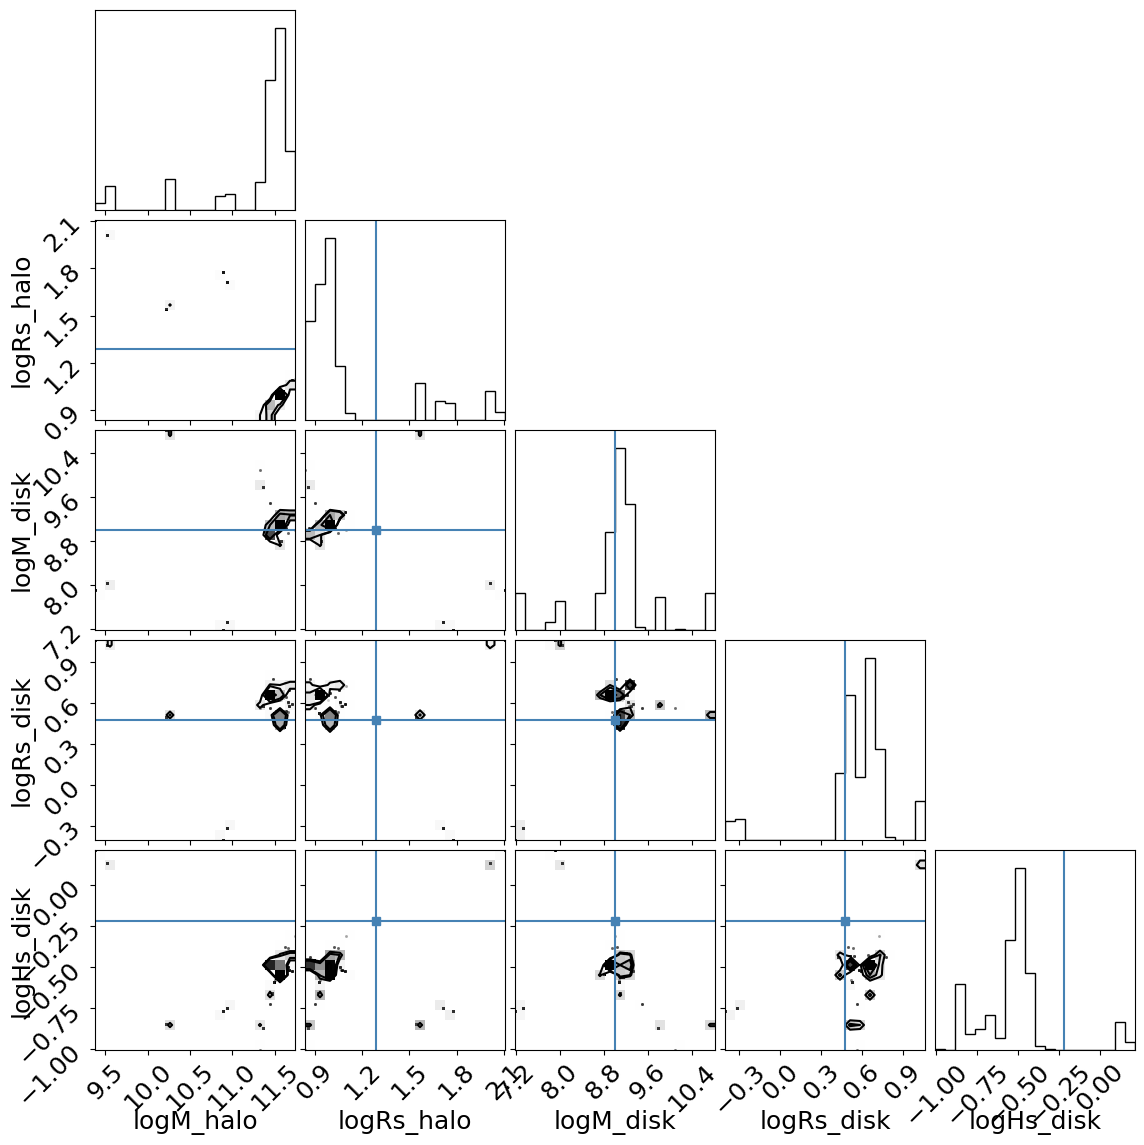

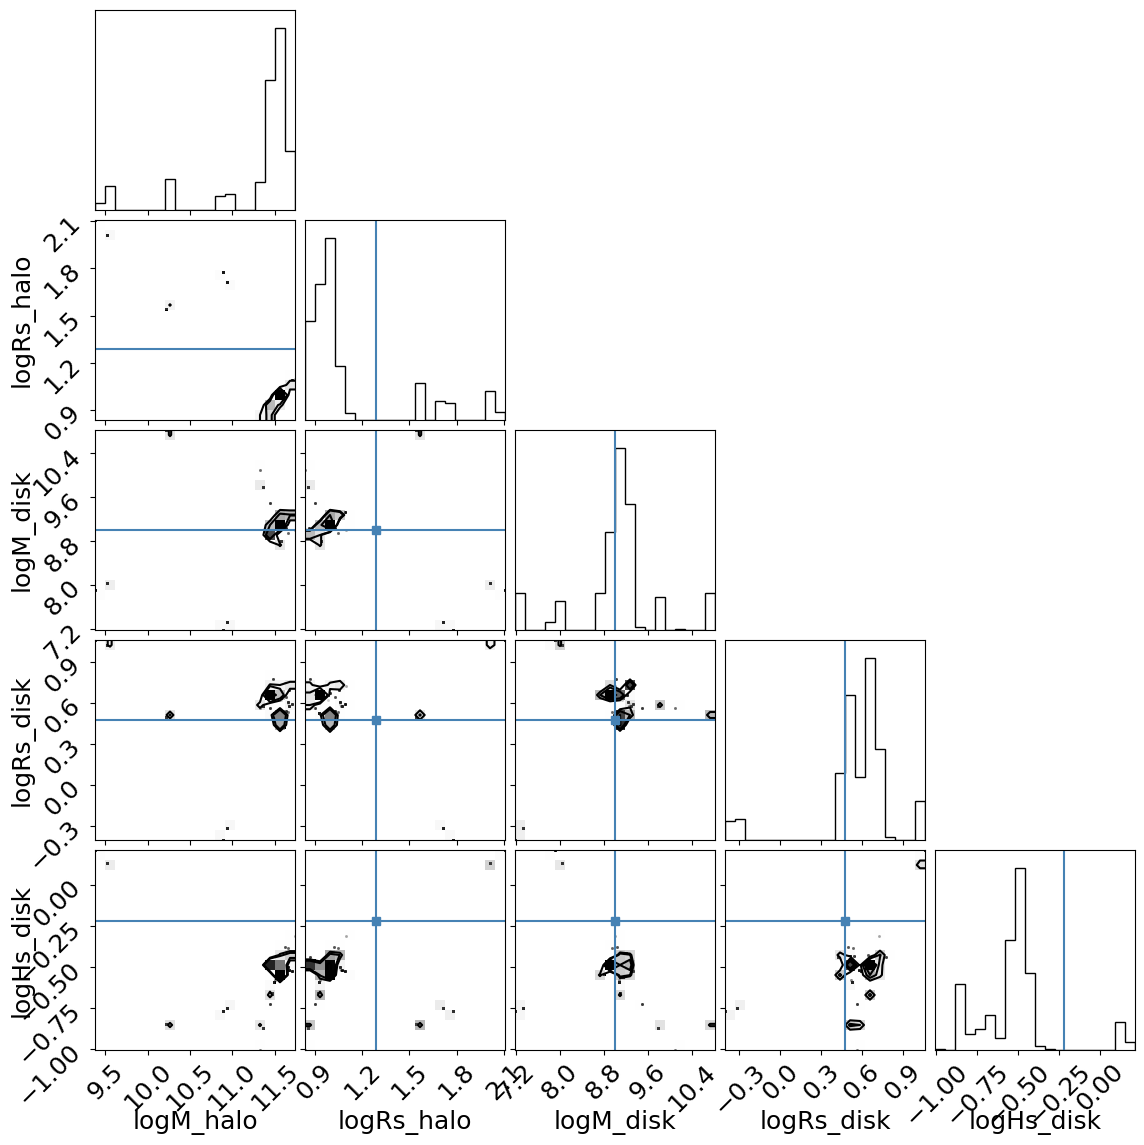

In [2]:
import pandas as pd


param_names = ['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

with open('/content/drive/MyDrive/SchwarMAX/axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}


# samples_plot = samples
samples_plot = pd.read_csv('/content/drive/MyDrive/SchwarMAX/test_posterior_0124.csv').to_numpy()
ground_truth_plot = [ground_truth[k] for k in param_names]
corner.corner(samples_plot, labels=param_names, truths=ground_truth_plot)

# Grid search solution

In [4]:
np.random.choice(10, size=5, replace=False)

array([9, 5, 7, 6, 2])

In [4]:
param_names = ['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

PATH_DATA = f'/content/drive/MyDrive/SchwarMAX'

save_file = PATH_DATA + f'/trail_sample.pkl'
save_sampler = PATH_DATA + f'/trail_sample_idata.nc'

with open(path + 'IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)

n_particles =  10_000

print(n_particles)
np.random.seed(42)
index = np.random.choice(len(ic['x']), size=n_particles, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T
# w0 = jnp.array([ic['x'], ic['y'], ic['z'], ic['vx'], ic['vy'], ic['vz']]).T

with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

df_Rzphi_data = pd.read_csv(path + 'axisymmetric_disc_Rzphi.csv')
df_XY_data = pd.read_csv(path + 'axisymmetric_disc_XY_kine.csv')

Rzphi_density_data = jnp.array(df_Rzphi_data['N_count'].to_numpy()).astype(jnp.float32)
XY_density_data = jnp.array(df_XY_data['N_count'].to_numpy()).astype(jnp.float32)
V_data = jnp.array(df_XY_data['V_mean'].to_numpy()).astype(jnp.float32)
V_data_err = jnp.array(0.1 * df_XY_data['V_mean'].to_numpy() + 1.0).astype(jnp.float32)
sigma_data = jnp.array(df_XY_data['V_sigma'].to_numpy()).astype(jnp.float32)
sigma_data_err = jnp.array(0.1 * df_XY_data['V_sigma'].to_numpy() + 1.0).astype(jnp.float32)
h1_data = jnp.array(df_XY_data['h1'].to_numpy()).astype(jnp.float32)
h1_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h1'].to_numpy()) + 0.1).astype(jnp.float32)
h2_data = jnp.array(df_XY_data['h2'].to_numpy()).astype(jnp.float32)
h2_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h2'].to_numpy()) + 0.1).astype(jnp.float32)
h3_data = jnp.array(df_XY_data['h3'].to_numpy()).astype(jnp.float32)
h3_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h3'].to_numpy()) + 0.1).astype(jnp.float32)
h4_data = jnp.array(df_XY_data['h4'].to_numpy()).astype(jnp.float32)
h4_data_err = jnp.array(0.1 * jnp.abs(df_XY_data['h4'].to_numpy()) + 0.1).astype(jnp.float32)
v0 = jnp.array(df_XY_data['v0_cell'].to_numpy()).astype(jnp.float32)
s = jnp.array(df_XY_data['s_cell'].to_numpy()).astype(jnp.float32)

non_empty_index = jnp.where(df_XY_data['nonempty'].to_numpy())[0]



dict_data = {
    'w0': w0,
    'v0': v0,
    's': s,
    'Rzphi_density_data': Rzphi_density_data,
    'XY_density_data': XY_density_data,
    'V_data': V_data,
    'V_data_err': V_data_err,
    'sigma_data': sigma_data,
    'sigma_data_err': sigma_data_err,
    'h1_data': h1_data,
    'h1_data_err': h1_data_err,
    'h2_data': h2_data,
    'h2_data_err': h2_data_err,
    'h3_data': h3_data,
    'h3_data_err': h3_data_err,
    'h4_data': h4_data,
    'h4_data_err': h4_data_err,
    'non_empty_index': non_empty_index
}


ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

prior_loc = {
    'logM_halo': ground_truth['logM_halo'],
    'logRs_halo': ground_truth['logRs_halo'],
    'logM_disk': ground_truth['logM_disk'],
    'logRs_disk': ground_truth['logRs_disk'],
    'logHs_disk': ground_truth['logHs_disk'],
}
prior_scales = {
    'logM_halo': 0.5,
    'logRs_halo': 0.5,
    'logM_disk': 0.5,
    'logRs_disk': 0.5,
    'logHs_disk': 0.5,
}
prior_uniform = {
    'logM_halo': [ground_truth['logM_halo']-3,ground_truth['logM_halo']+3],
    'logRs_halo': [ground_truth['logRs_halo']-1, ground_truth['logRs_halo']+1],
    'logM_disk': [ground_truth['logM_disk']-3, ground_truth['logM_disk']+3],
    'logRs_disk': [ground_truth['logRs_disk']-1, ground_truth['logRs_disk']+1],
    'logHs_disk': [ground_truth['logHs_disk']-1, ground_truth['logHs_disk']+1],
}


# def log_prior(params):
#     logp = 0.0
#     for key in params.keys():
#         scale = prior_scales[key]
#         logp += -0.5 * ((params[key] - ground_truth[key]) / scale) ** 2
#     return logp
def log_prior(params):

  for key in params.keys():
    if params[key] < prior_uniform[key][0] or params[key] > prior_uniform[key][1]:
      return -np.inf
  return 0

def log_prob(theta):
    params = {name: theta[i] for i, name in enumerate(param_names)}
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = float(logl(params, dict_data))  # convert from JAX array
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

n_grid = 1000
param_grid = pd.read_csv('/content/drive/MyDrive/SchwarMAX/quasi_random_samples_5D_unity.csv').to_numpy()
index = np.random.choice(len(param_grid), size=n_grid, replace=False)
param_grid = param_grid[index]
param_grid[:, 0] = (param_grid[:, 0] - 0.5) * 6 + ground_truth['logM_halo']
param_grid[:, 1] = (param_grid[:, 1] - 0.5) * 2 + ground_truth['logRs_halo']
param_grid[:, 2] = (param_grid[:, 2] - 0.5) * 6 + ground_truth['logM_disk']
param_grid[:, 3] = (param_grid[:, 3] - 0.5) * 2 + ground_truth['logRs_disk']
param_grid[:, 4] = (param_grid[:, 4] - 0.5) * 2 + ground_truth['logHs_disk']

log_prob_grid = []
for i in tqdm(range(n_grid)):
  log_prob_grid.append(log_prob(param_grid[i]))
log_prob_grid = np.array(log_prob_grid)

pd.DataFrame({
    'logM_halo': param_grid[:, 0],
    'logRs_halo': param_grid[:, 1],
    'logM_disk': param_grid[:, 2],
    'logRs_disk': param_grid[:, 3],
    'logHs_disk': param_grid[:, 4],
    'log_prob': log_prob_grid,
}).to_csv('/content/drive/MyDrive/SchwarMAX/grid_search_result_0126.csv', index=False)

10000


100%|██████████| 1000/1000 [3:29:35<00:00, 12.58s/it]


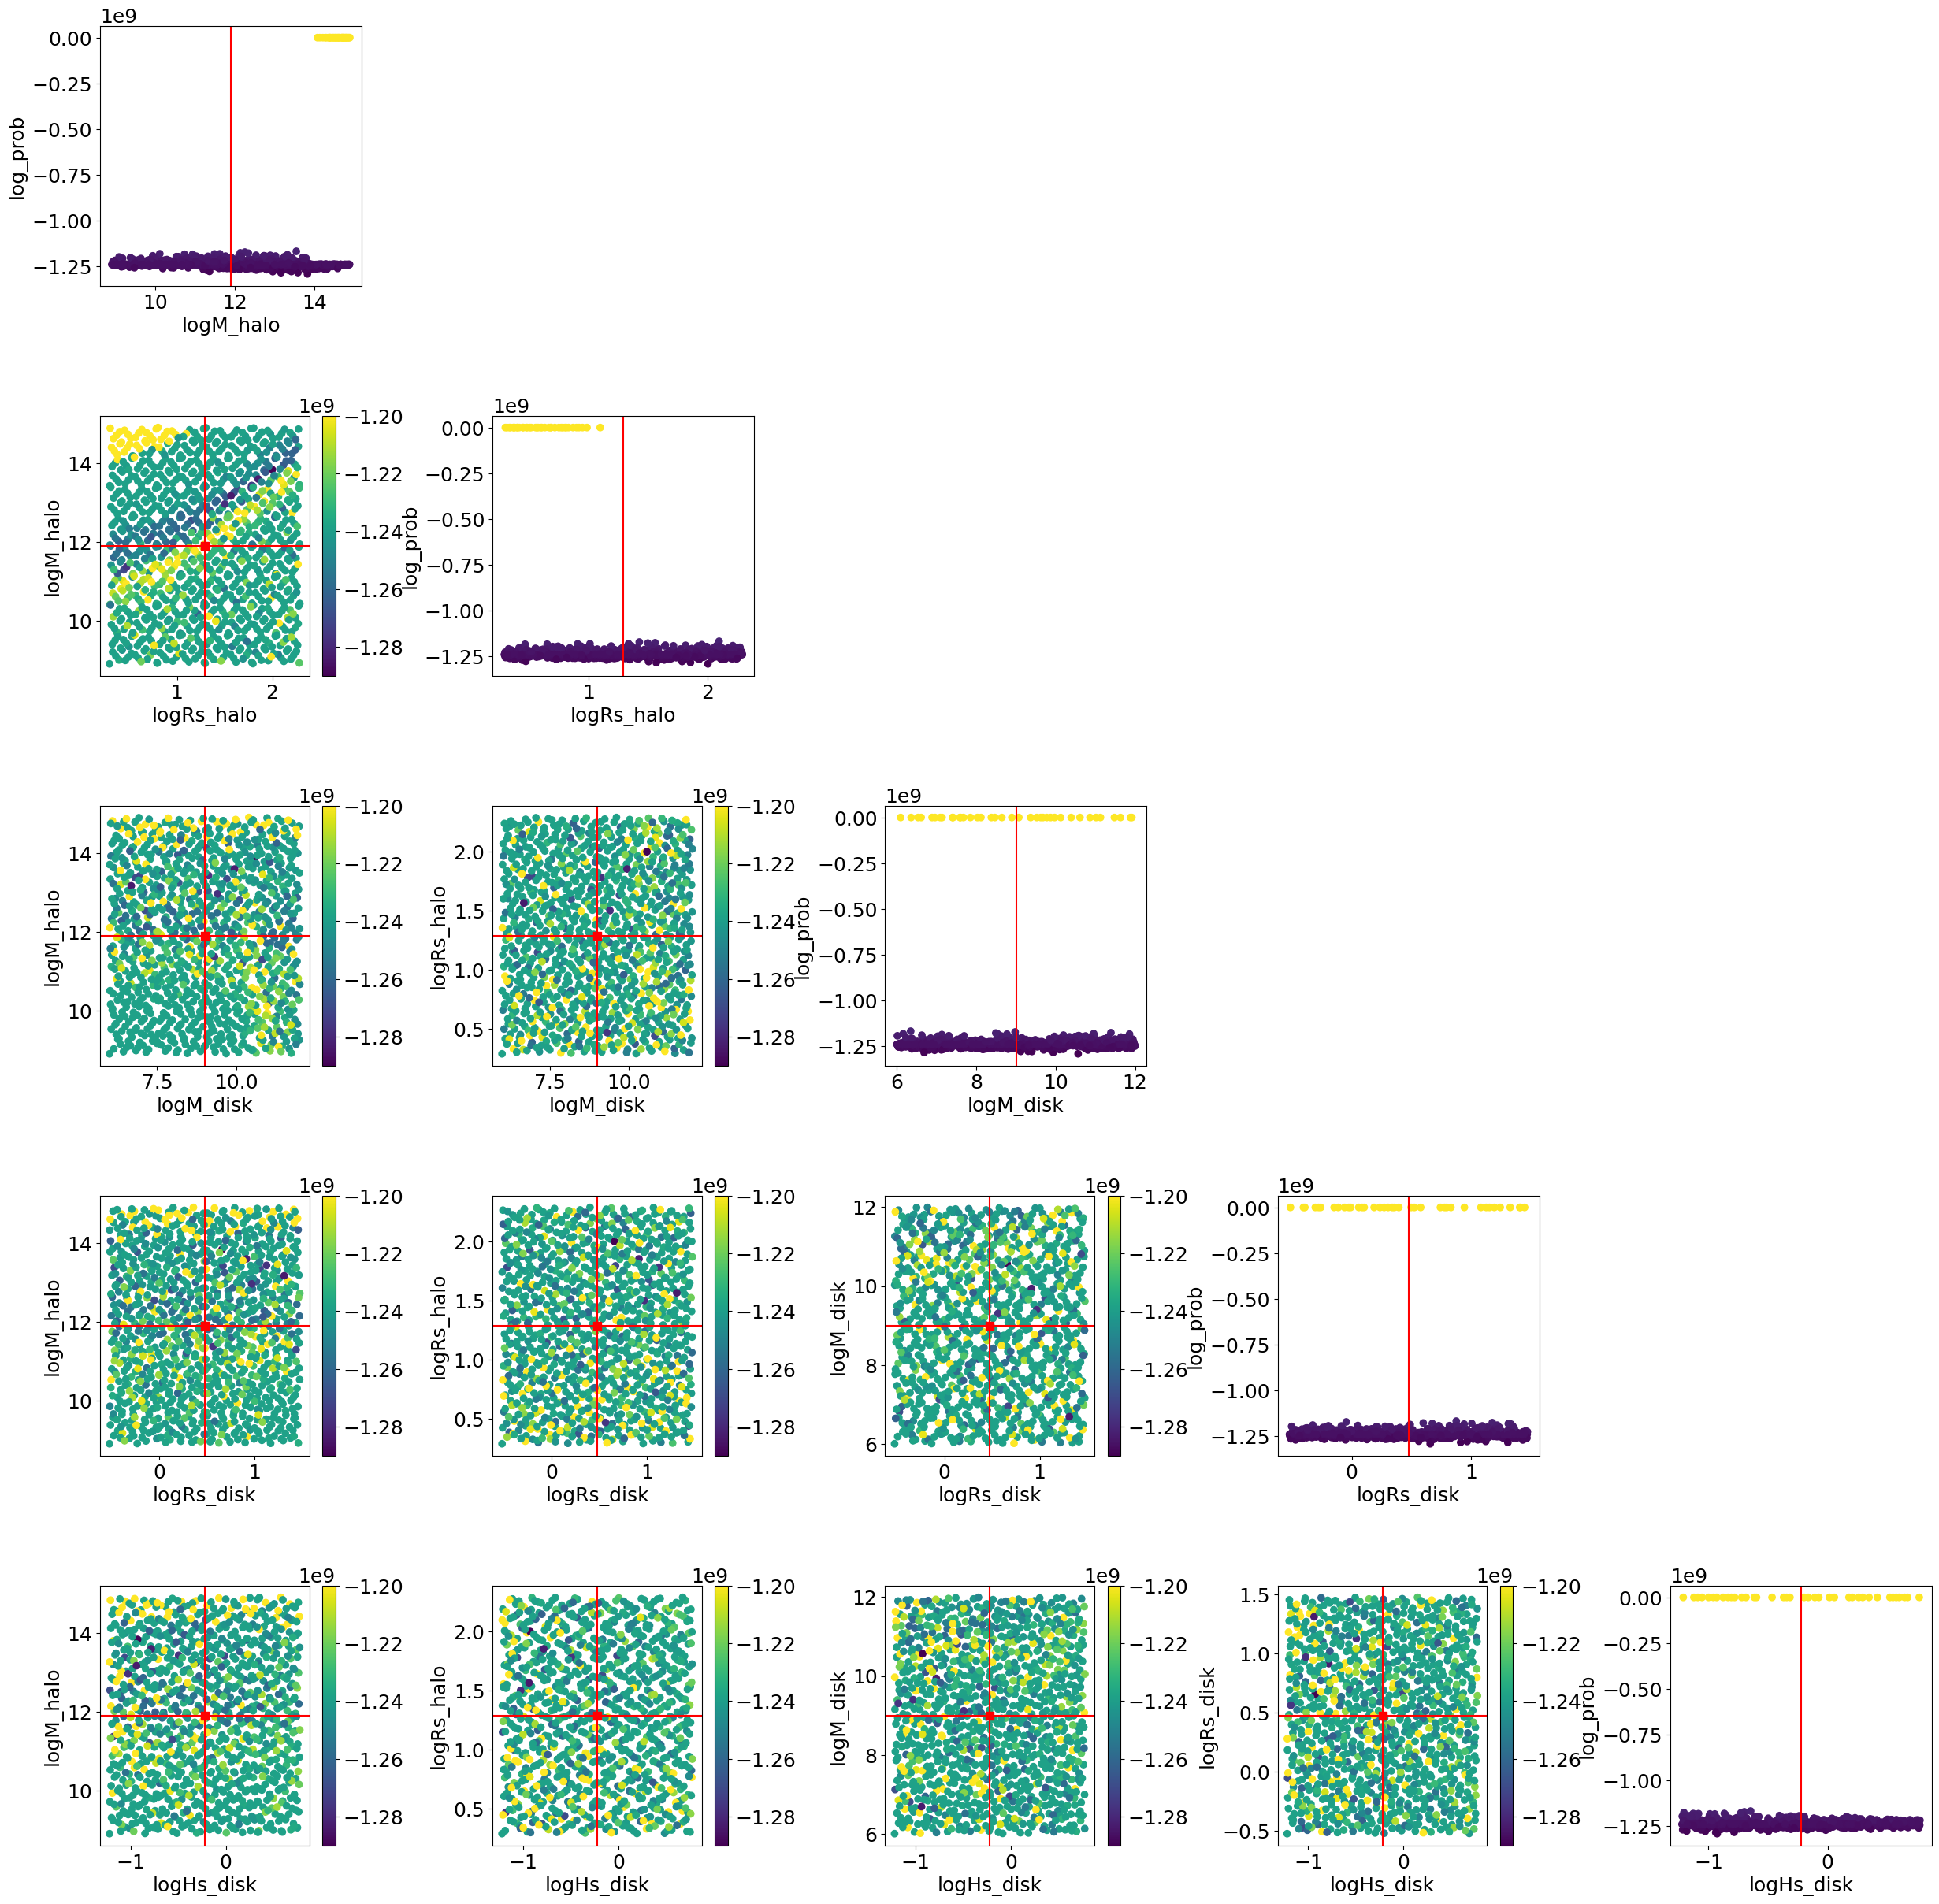

In [2]:
param_names = ['logM_halo', 'logRs_halo', 'logM_disk', 'logRs_disk', 'logHs_disk']

PATH_DATA = f'/content/drive/MyDrive/SchwarMAX'
with open(path + 'axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)

ground_truth = {
        'logM_halo': jnp.log10(0.8*10**12).item(),
        'logRs_halo': jnp.log10(data['ground_truth']['halo_params']['scaleRadius']).item(),
        'logM_disk': jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
        'logRs_disk': jnp.log10(data['ground_truth']['disc_params']['Rd']).item(),
        'logHs_disk': jnp.log10(data['ground_truth']['disc_params']['hz']).item(),
}

df_param = pd.read_csv('/content/drive/MyDrive/SchwarMAX/grid_search_result_0123.csv')

fig, ax = plt.subplots(len(param_names), len(param_names), figsize = (6* len(param_names), 6* len(param_names)),
                       gridspec_kw={'hspace': 0.5, 'wspace': 0.5})

for i in range (len(param_names)):
  for j in range (len(param_names)):

    if i>j:
      cb = ax[i,j].scatter(df_param[param_names[i]], df_param[param_names[j]], c=df_param['log_prob'], cmap='viridis', vmax = -1.2e9)
      ax[i,j].set_xlabel(param_names[i])
      ax[i,j].set_ylabel(param_names[j])
      ax[i,j].axvline(x=ground_truth[param_names[i]], color='red')
      ax[i,j].axhline(y=ground_truth[param_names[j]], color='red')
      ax[i,j].scatter(ground_truth[param_names[i]], ground_truth[param_names[j]], color='red', marker='s', s=50)
      fig.colorbar(cb, ax = ax[i,j])

    elif i<j:
      ax[i,j].set_axis_off()

    else:
      ax[i,j].scatter(df_param[param_names[i]], df_param['log_prob'], c=df_param['log_prob'], cmap='viridis')
      ax[i,j].set_xlabel(param_names[i])
      ax[i,j].set_ylabel('log_prob')
      ax[i,j].axvline(x=ground_truth[param_names[i]], color='red')
      # ax[i,j].set(ylim=[-1.3e9, -1.1e9])